# Grid Experiments

Runs the full pipeline (sampling → processing → HCC → words/POU) for all combinations of
grid size and district count defined in `CONFIGS` below.

## Config

In [1]:
# (grid_size N, num_districts k)
CONFIGS = [
    (4, 2)
]

CYCLE_WALK_STEPS = "1e7"
POP_DEV          = 0.1
MAX_SAMPLES      = 10000
MIN_STEP         = 100
NUM_LETTERS      = 20
WORD_DEGREE      = 10
TEMP             = 0.0

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_graph, generate_grid_shape
from hierachical import HClusters
from sample import SampleProcessor
from utils import plot_words_list
from word import PlanWordBuilder, WordStat


def graph_fn(N, k):   return f"data/graph/grid_{N}x{N}_k{k}.json"
def sample_fn(N, k):  return f"local/output/grid{N}x{N}_k{k}/atlas.jsonl.gz"
def out_dir(N, k):    return f"local/output/grid{N}x{N}_k{k}/processed"

/Users/ag245/.pyenv/versions/3.13.0/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Generate graph JSONs

Creates one JSON file per (N, k) combo in `data/graph/`. Safe to re-run.

In [3]:
Path("data/graph").mkdir(parents=True, exist_ok=True)

for N, k in CONFIGS:
    fn = graph_fn(N, k)
    generate_grid_graph(N=N, filename=fn, num_districts=k)
    print(f"wrote {fn}")

wrote data/graph/grid_4x4_k2.json


## Step 2 — Run Julia sampler

Each call below runs the CycleWalk MCMC for one (N, k) combo.
Output lands in `local/output/grid{N}x{N}_k{k}/atlas.jsonl.gz`.

**This cell is slow** — run once and skip on subsequent notebook executions
(the analysis cells check for the output file before resampling).

In [4]:
import subprocess

for N, k in CONFIGS:
    out = Path(sample_fn(N, k))
    if out.exists():
        print(f"skipping {N}x{N} k={k} — output already exists")
        continue
    out.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        "./sampling/run.sh",
        "--map-file",           graph_fn(N, k),
        "--output-file",        str(out),
        "--cycle-walk-steps",   CYCLE_WALK_STEPS,
        "--pop-dev",            str(POP_DEV),
    ]
    print(f"sampling {N}x{N} k={k} …")
    result = subprocess.run(cmd, capture_output=False, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"sampler failed for {N}x{N} k={k}")
    print(f"  done → {out}")

sampling 4x4 k=2 …


  Activating project at `~/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/sampling/runCycleWalkEnv`


output_file_path = /Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/local/output/grid4x4_k2/atlas.jsonl.gz
  done → local/output/grid4x4_k2/atlas.jsonl.gz


## Step 3 — Process samples and build HCC linkage

For each combo: reads the JSONL.gz, deduplicates districts, writes Feather artifacts,
computes the pairwise distance matrix, and runs HCC. Cached — re-running this cell
skips combos whose `processed/` directory already contains all artifacts.

In [5]:
processors = {}

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    print(f"\n=== {tag} ===")
    sp = SampleProcessor(graph_fn(N, k), out_dir(N, k))

    if Path(out_dir(N, k), "linkage.npy").exists():
        print("  loading cached artifacts")
        sp.load_processed()
    else:
        sp.clean()
        sp.process_samples(
            [sample_fn(N, k)],
            max_length=MAX_SAMPLES,
            min_step=MIN_STEP,
        )
        sp.load_processed()
        sp.load_distance_matrix()
        sp.ensure_linkage()
        print(f"  districts: {len(sp.df_districts)}  unique plans: {len(sp.df_distributions)}")

    processors[tag] = sp

print("\ndone")


=== 4x4_k2 ===
Reading local/output/grid4x4_k2/atlas.jsonl.gz


100%|██████████| 8385/8385 [00:00<00:00, 91534.36it/s]

  districts: 130  unique plans: 65

done


## Step 4 — Letters, Words, and POU

Cuts the HCC dendrogram at `NUM_LETTERS` clusters, refines centroids with k-medoids,
runs beam-search word assignment, and computes the stationary distribution.

In [7]:
results = {}

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    print(f"\n=== {tag} ===")
    sp = processors[tag]

    num_districts = len(sp.df_districts)
    num_letters = min(NUM_LETTERS, num_districts - 1)

    hc = HClusters(sp)
    hc.update_clusters(num_letters)
    hc.kcentroids()

    pw = PlanWordBuilder(
        sp, hc,
        word_degree=WORD_DEGREE,
        verbose=False,
        centroid_norm="l1",
    ).build()

    ws = WordStat(pw, temp=TEMP, verbose=False)

    results[tag] = dict(sp=sp, hc=hc, pw=pw, ws=ws)
    print(f"  words: {pw.df_words.word_uid.nunique()}  plans covered: {pw.df_words.plan_uid.nunique()}")

print("\ndone")


=== 4x4_k2 ===


  6%|▌         | 3/50 [00:00<00:00, 137.33it/s]

epoch 0: rel_improvement = 0.08536585365853659
epoch 1: rel_improvement = 0.013333333333333334
epoch 2: rel_improvement = 0.018018018018018018
  words: 90  plans covered: 65

done


## Step 5 — Stationary distributions

Top words by stationary weight for each combo.

In [8]:
TOP_N = 5

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    ws = results[tag]["ws"]
    df_top = ws.stationary_table().head(TOP_N).reset_index(drop=True)
    print(f"\n=== {tag} — top {TOP_N} words ===")
    print(df_top[["word_str", "stationary"]].to_string(index=False))


=== 4x4_k2 — top 5 words ===
word_str  stationary
   18.19     0.30880
   12.13     0.03890
     8.9     0.03720
   12.15     0.03704
     7.9     0.03667


/Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/word.py:315: RuntimeWarning: invalid value encountered in multiply
  df_words["phi"] = np.exp(-self.temp * (ratio - 1.0))


## Step 6 — Visualize top words per combo

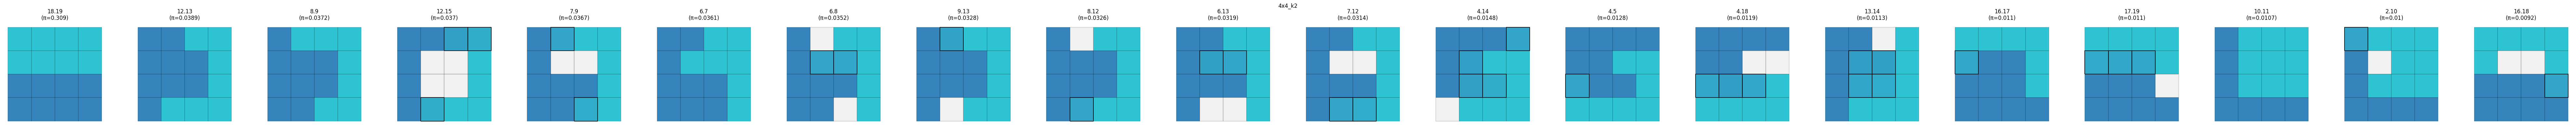

In [9]:
from utils import plot_words_centroids

TOP_VIZ = 20

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    r   = results[tag]
    ws  = r["ws"]
    hc  = r["hc"]
    gdf = generate_grid_shape(N)

    df_top = ws.stationary_table().head(TOP_VIZ).reset_index(drop=True)
    fig, axes = plt.subplots(1, TOP_VIZ, figsize=(4 * TOP_VIZ, 4))
    fig.suptitle(tag)
    for i, row in df_top.iterrows():
        ax = axes[i] if TOP_VIZ > 1 else axes
        plot_words_centroids(gdf, hc.cluster_densities, row.word, ltr=True, ax=ax)
        ax.set_title(f"{row.word_str}\n(π={row.stationary:.3g})")
    plt.tight_layout()
    plt.show()

## Step 7 — Flux matrices

TypeError: 'Axes' object is not iterable

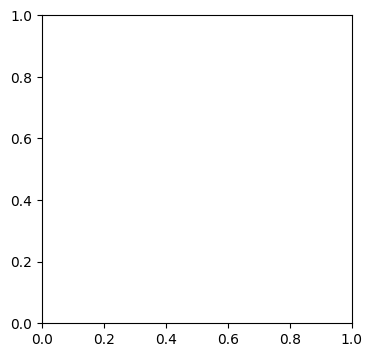

In [10]:
ncols = len(CONFIGS)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

for ax, (N, k) in zip(axes, CONFIGS):
    tag = f"{N}x{N}_k{k}"
    ws  = results[tag]["ws"]
    im  = ax.imshow(ws.flux_matrix(), aspect="auto")
    ax.set_title(tag)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## All unique districts — 4×4 grid, 2 partitions

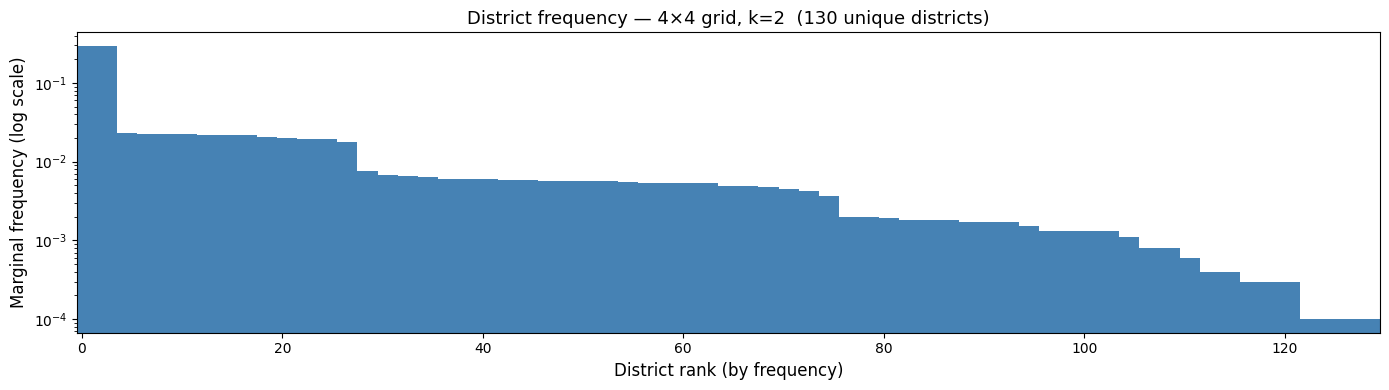

In [12]:
import pandas as pd
from utils import str_to_vec

N, k = 4, 2

def isoperimetric_ratio(district_cells, grid_n):
    s = set(district_cells)
    perimeter = 0
    for c in s:
        r, col = divmod(c, grid_n)
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, col + dc
            if not (0 <= nr < grid_n and 0 <= nc < grid_n):
                perimeter += 1
            elif nr * grid_n + nc not in s:
                perimeter += 1
    return perimeter / len(s) ** 0.5

# build per-district marginal counts
df_districts = pd.read_feather(f"local/output/grid{N}x{N}_k{k}/processed/districts.feather")
df_dist      = pd.read_feather(f"local/output/grid{N}x{N}_k{k}/processed/distributions.feather")

total_plans = df_dist["count"].sum()
district_counts = {}
for _, row in df_dist.iterrows():
    for uid in [int(u) for u in row["plan_str"].split(".")]:
        district_counts[uid] = district_counts.get(uid, 0) + row["count"]

df_districts["count"] = df_districts["district_uid"].map(district_counts).fillna(0).astype(int)
df_districts["freq"]  = df_districts["count"] / total_plans
df_sorted = df_districts.sort_values("count", ascending=False).reset_index(drop=True)

# semi-log frequency bar chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(df_sorted)), df_sorted["freq"], width=1.0, color="steelblue", linewidth=0)
ax.set_yscale("log")
ax.set_xlabel("District rank (by frequency)", fontsize=12)
ax.set_ylabel("Marginal frequency (log scale)", fontsize=12)
ax.set_title(f"District frequency — {N}×{N} grid, k={k}  ({len(df_sorted)} unique districts)", fontsize=13)
ax.set_xlim(-0.5, len(df_sorted) - 0.5)
plt.tight_layout()
plt.show()

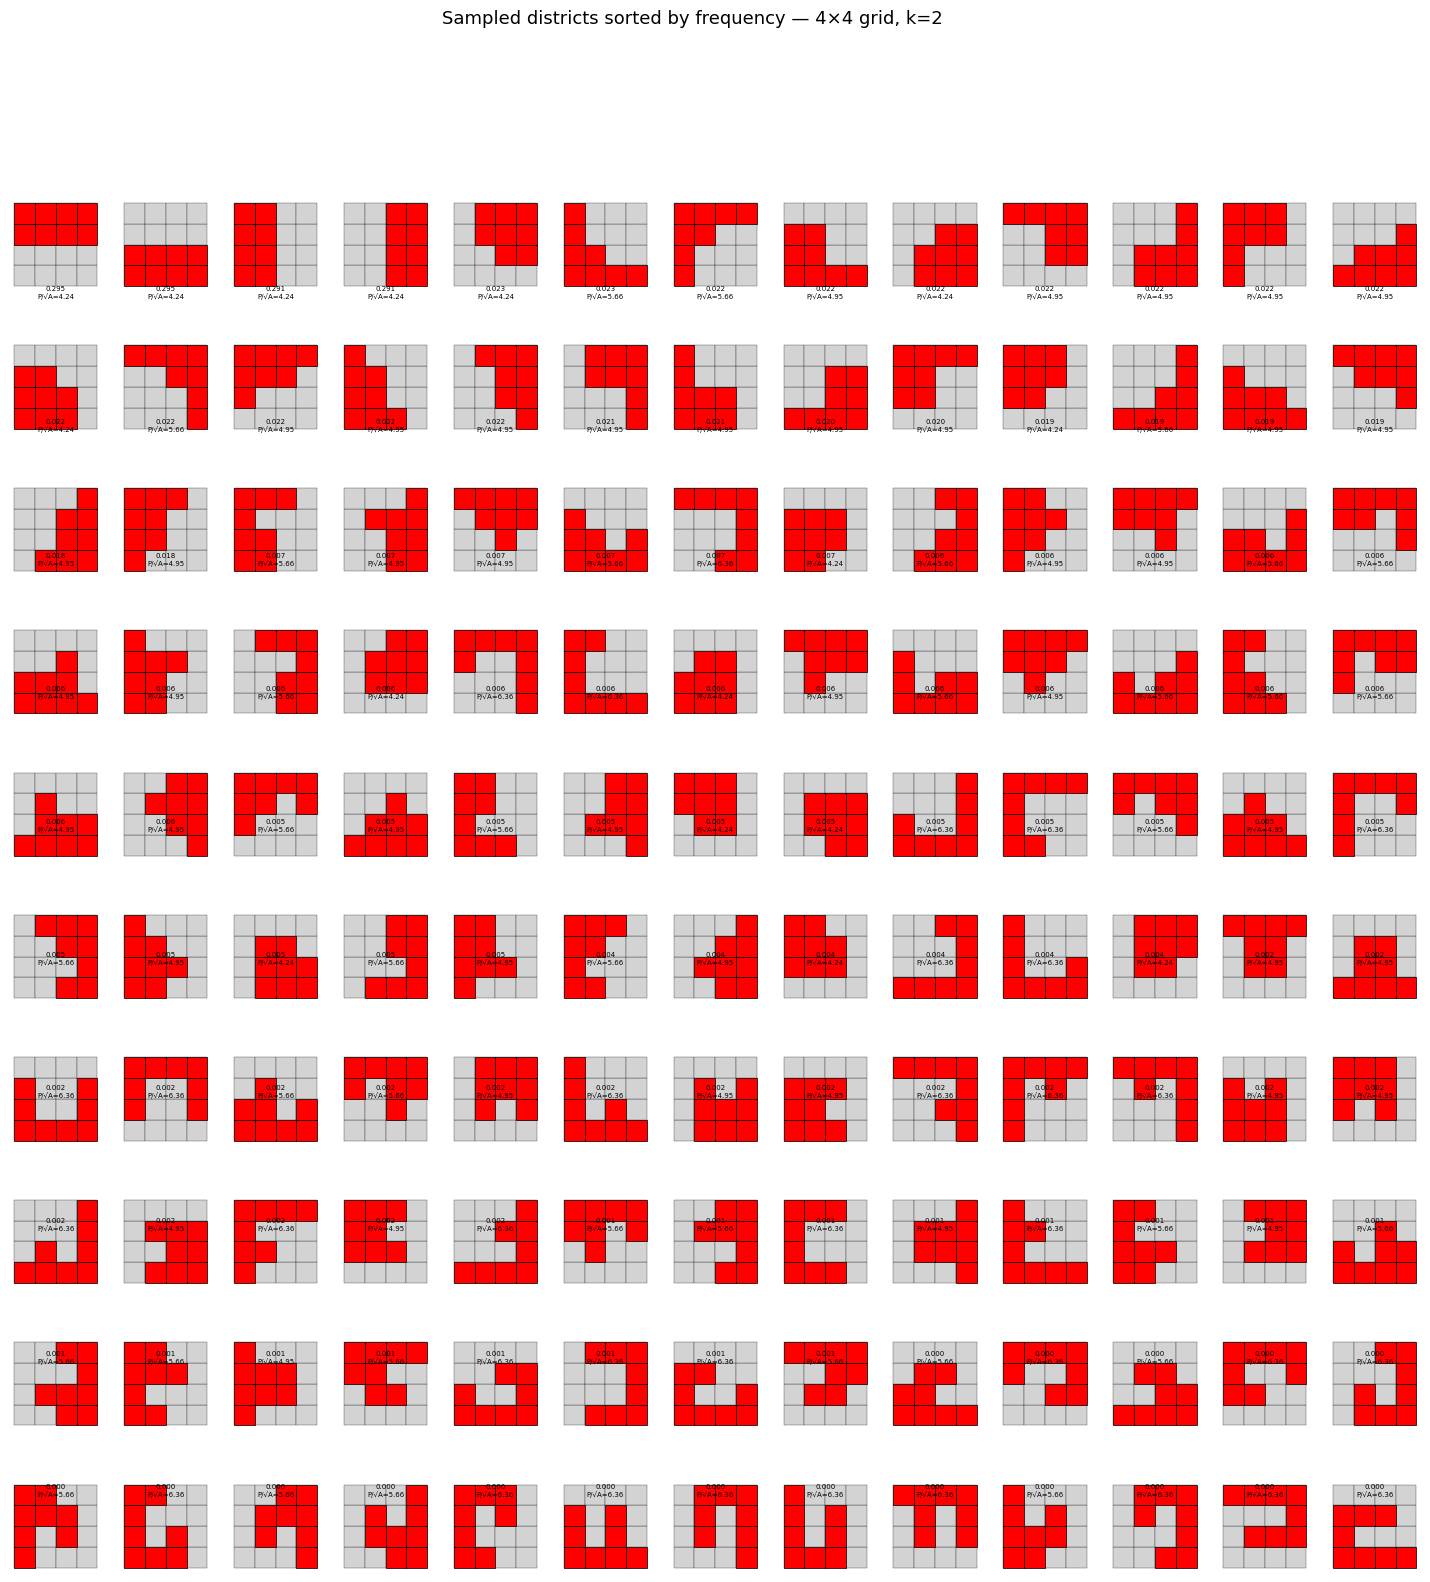

In [13]:
import math
from utils import plot_district

gdf = generate_grid_shape(N)

# df_sorted and isoperimetric_ratio come from the cell above
ncols = 13
nrows = math.ceil(len(df_sorted) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.4, nrows * 1.7))
fig.suptitle(f"Sampled districts sorted by frequency — {N}×{N} grid, k={k}", fontsize=13)

for i, ax in enumerate(axes.flat):
    if i < len(df_sorted):
        plot_district(gdf, str_to_vec(df_sorted.iloc[i]["district_str"]), ax=ax)
    else:
        ax.set_visible(False)

fig.canvas.draw()
for i, ax in enumerate(axes.flat):
    if i < len(df_sorted):
        row = df_sorted.iloc[i]
        ratio = isoperimetric_ratio(str_to_vec(row["district_str"]).tolist(), N)
        pos = ax.get_position()
        fig.text(
            pos.x0 + pos.width / 2, pos.y0 - 0.003,
            f"{row['freq']:.3f}\nP/√A={ratio:.2f}",
            ha="center", va="top", fontsize=5,
        )

plt.subplots_adjust(bottom=0.05, hspace=0.1)
plt.show()

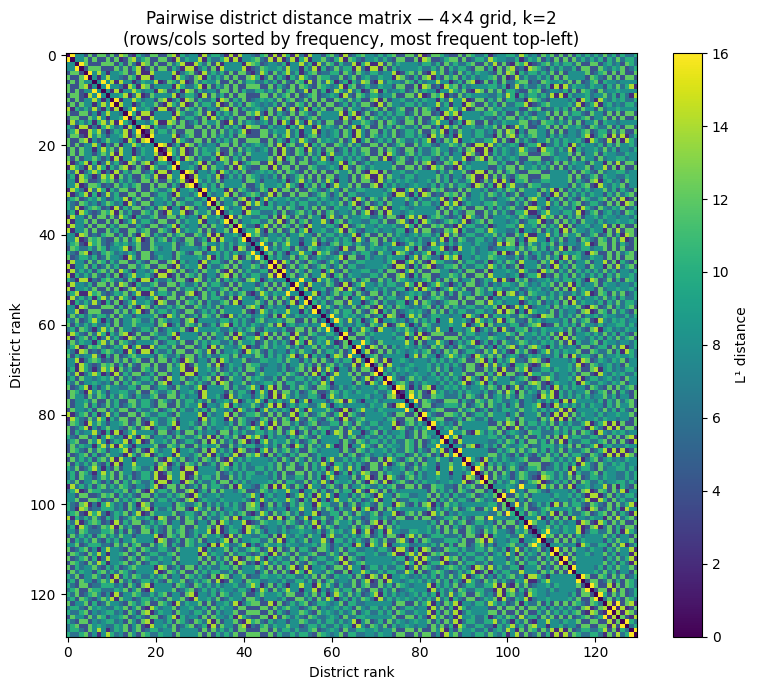

In [14]:
# distance matrix — rows/cols reordered by frequency rank (matches df_sorted above)
D = np.load(f"local/output/grid{N}x{N}_k{k}/processed/distance_matrix.npy")

freq_order = df_sorted["district_uid"].values
D_ordered  = D[np.ix_(freq_order, freq_order)]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(D_ordered, aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax, label="L¹ distance")
ax.set_title(
    f"Pairwise district distance matrix — {N}×{N} grid, k={k}\n"
    f"(rows/cols sorted by frequency, most frequent top-left)",
    fontsize=12,
)
ax.set_xlabel("District rank")
ax.set_ylabel("District rank")
plt.tight_layout()
plt.show()

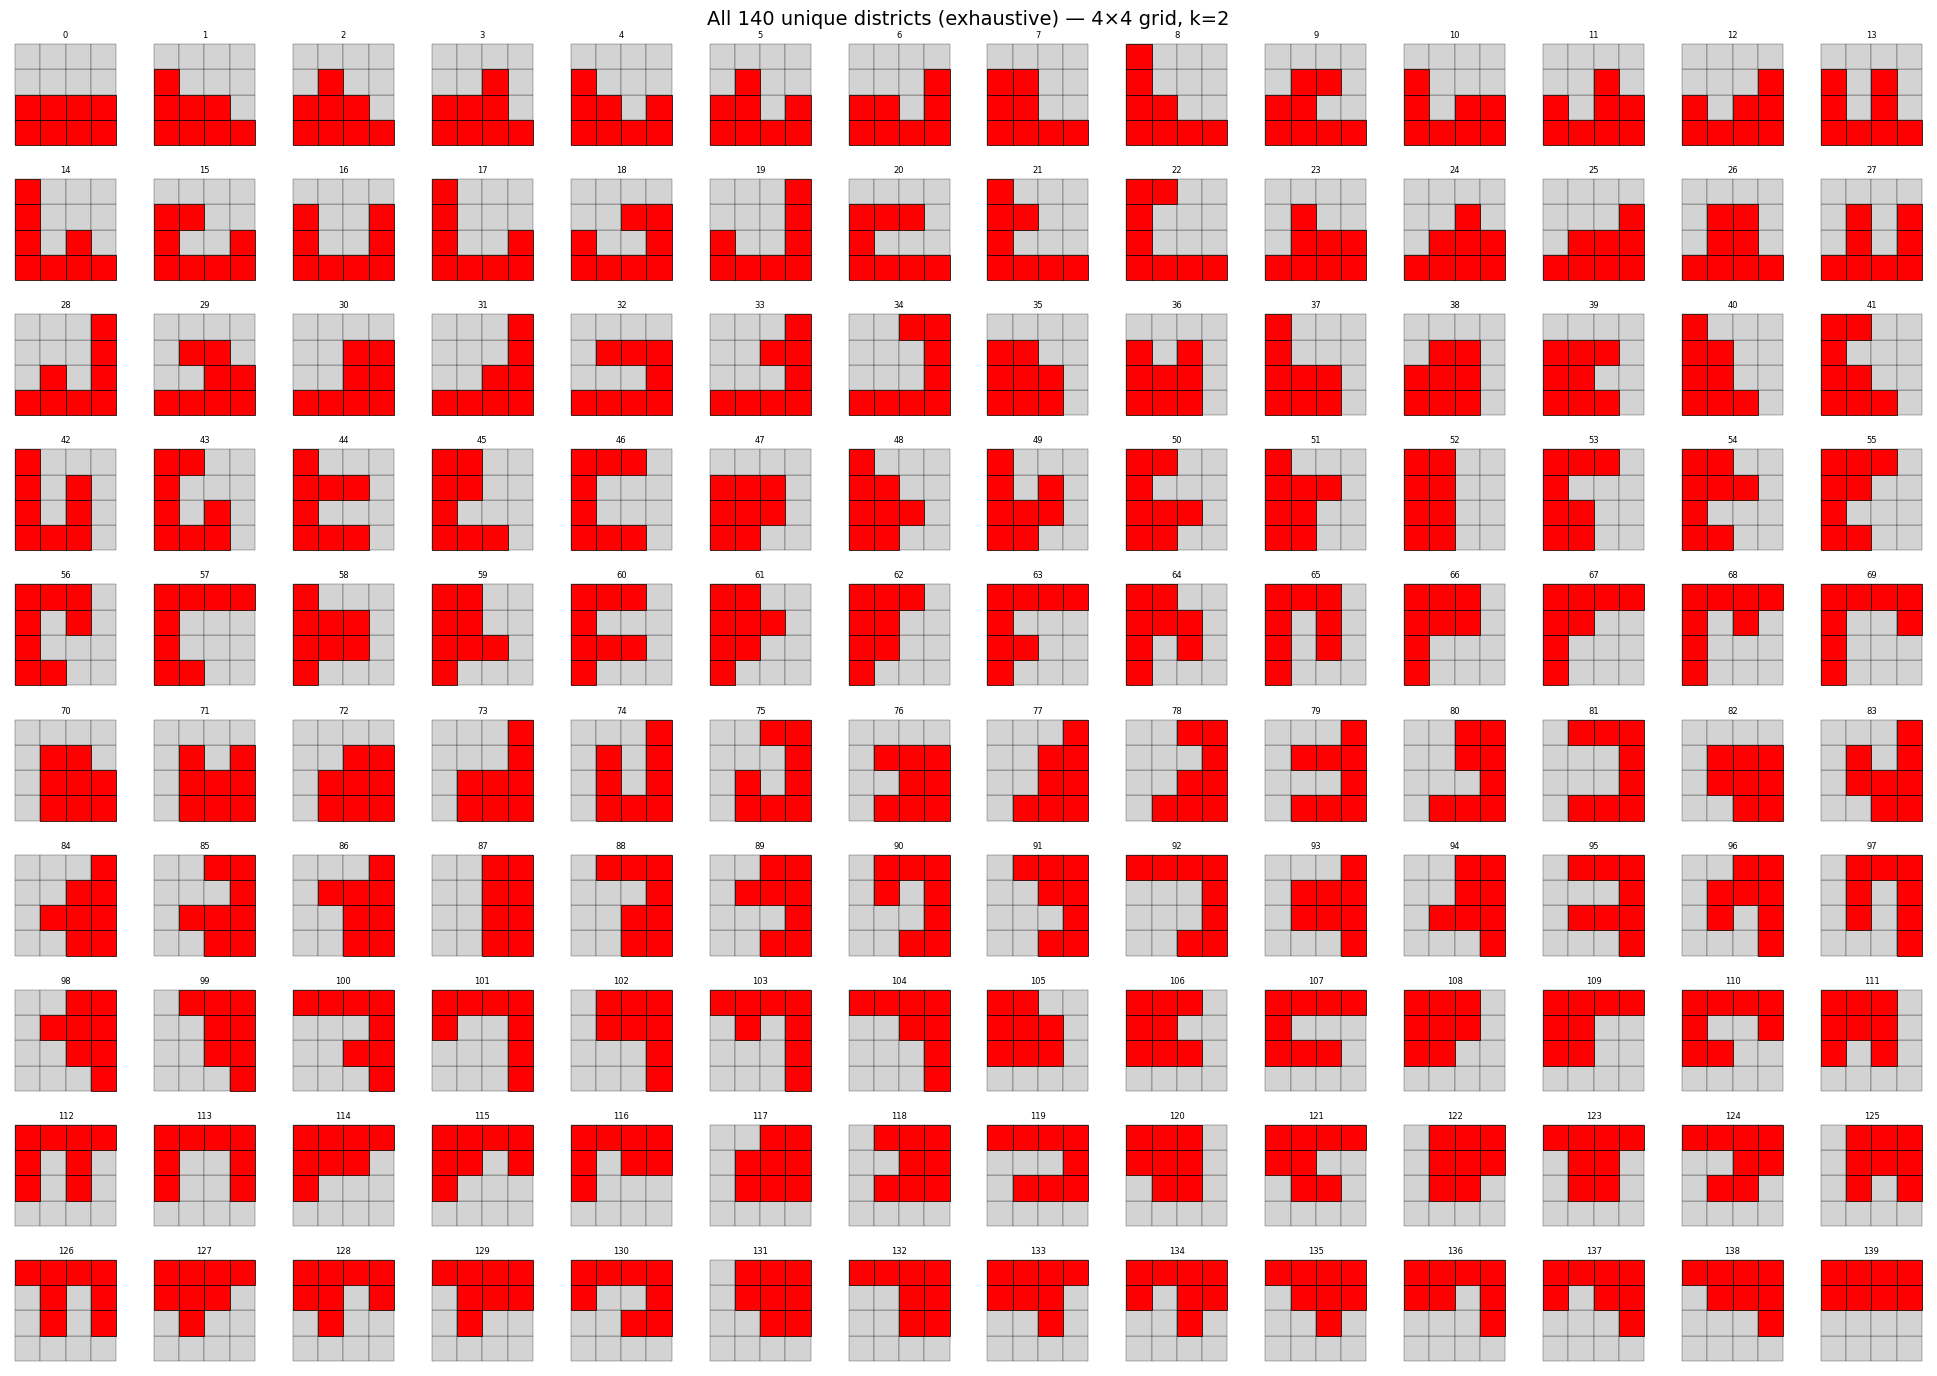

In [15]:
from itertools import combinations

N, k = 4, 2
gdf = generate_grid_shape(N)
cells = list(range(N * N))
per_district = N * N // k

def _neighbors_4x4(c):
    r, col = divmod(c, N)
    nbrs = []
    if r > 0:     nbrs.append(c - N)
    if r < N - 1: nbrs.append(c + N)
    if col > 0:   nbrs.append(c - 1)
    if col < N - 1: nbrs.append(c + 1)
    return nbrs

def _connected(subset):
    s = set(subset)
    start = next(iter(s))
    visited = {start}
    queue = [start]
    while queue:
        node = queue.pop()
        for nb in _neighbors_4x4(node):
            if nb in s and nb not in visited:
                visited.add(nb); queue.append(nb)
    return len(visited) == len(s)

all_districts = sorted(
    {d
     for half in combinations(cells, per_district)
     if _connected(half) and _connected([c for c in cells if c not in half])
     for d in (half, tuple(c for c in cells if c not in half))},
    key=lambda d: (len(d), d)
)

ncols = 14
nrows = math.ceil(len(all_districts) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.4, nrows * 1.4))
fig.suptitle(f"All {len(all_districts)} unique districts (exhaustive) — {N}×{N} grid, k={k}", fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < len(all_districts):
        plot_district(gdf, np.array(all_districts[i]), ax=ax)
        ax.set_title(str(i), fontsize=6, pad=1)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

sampled: 130  exhaustive: 140  missing: 10


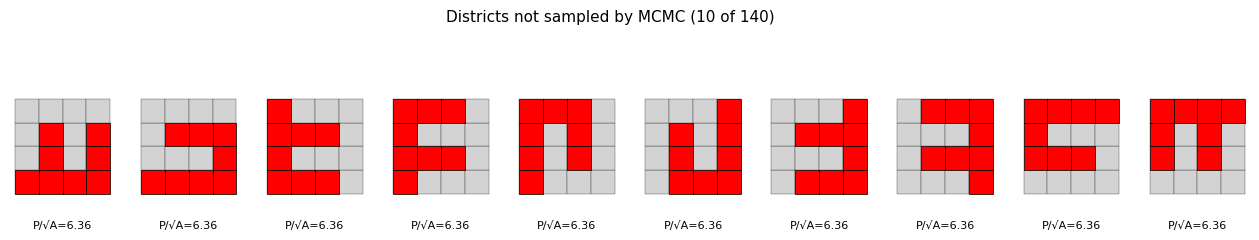

In [16]:
import pandas as pd
from utils import plot_district, str_to_vec

N, k = 4, 2
gdf = generate_grid_shape(N)

def isoperimetric_ratio(district_cells, grid_n):
    s = set(district_cells)
    perimeter = 0
    for c in s:
        r, col = divmod(c, grid_n)
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, col + dc
            if not (0 <= nr < grid_n and 0 <= nc < grid_n):
                perimeter += 1
            elif nr * grid_n + nc not in s:
                perimeter += 1
    return perimeter / len(s) ** 0.5

df_sampled = pd.read_feather(f"local/output/grid{N}x{N}_k{k}/processed/districts.feather")
sampled_set = {frozenset(str_to_vec(s).tolist()) for s in df_sampled["district_str"]}
exhaustive_set = {frozenset(d) for d in all_districts}

missing = sorted(exhaustive_set - sampled_set, key=lambda d: tuple(sorted(d)))
print(f"sampled: {len(sampled_set)}  exhaustive: {len(exhaustive_set)}  missing: {len(missing)}")

ncols = len(missing)
fig, axes = plt.subplots(1, ncols, figsize=(ncols * 1.6, 2.8))
fig.suptitle(
    f"Districts not sampled by MCMC ({len(missing)} of {len(exhaustive_set)})",
    fontsize=11, y=1.02,
)

ratios = []
for ax, d in zip(axes, missing):
    cells = sorted(d)
    ratio = isoperimetric_ratio(cells, N)
    ratios.append(ratio)
    plot_district(gdf, np.array(cells), ax=ax)

# draw labels after all plots so positions are stable
fig.canvas.draw()
for ax, ratio in zip(axes, ratios):
    pos = ax.get_position()          # figure-fraction coords
    fig.text(
        pos.x0 + pos.width / 2,
        pos.y0 - 0.04,
        f"P/√A={ratio:.2f}",
        ha="center", va="top", fontsize=8,
    )

plt.subplots_adjust(bottom=0.18)
plt.show()

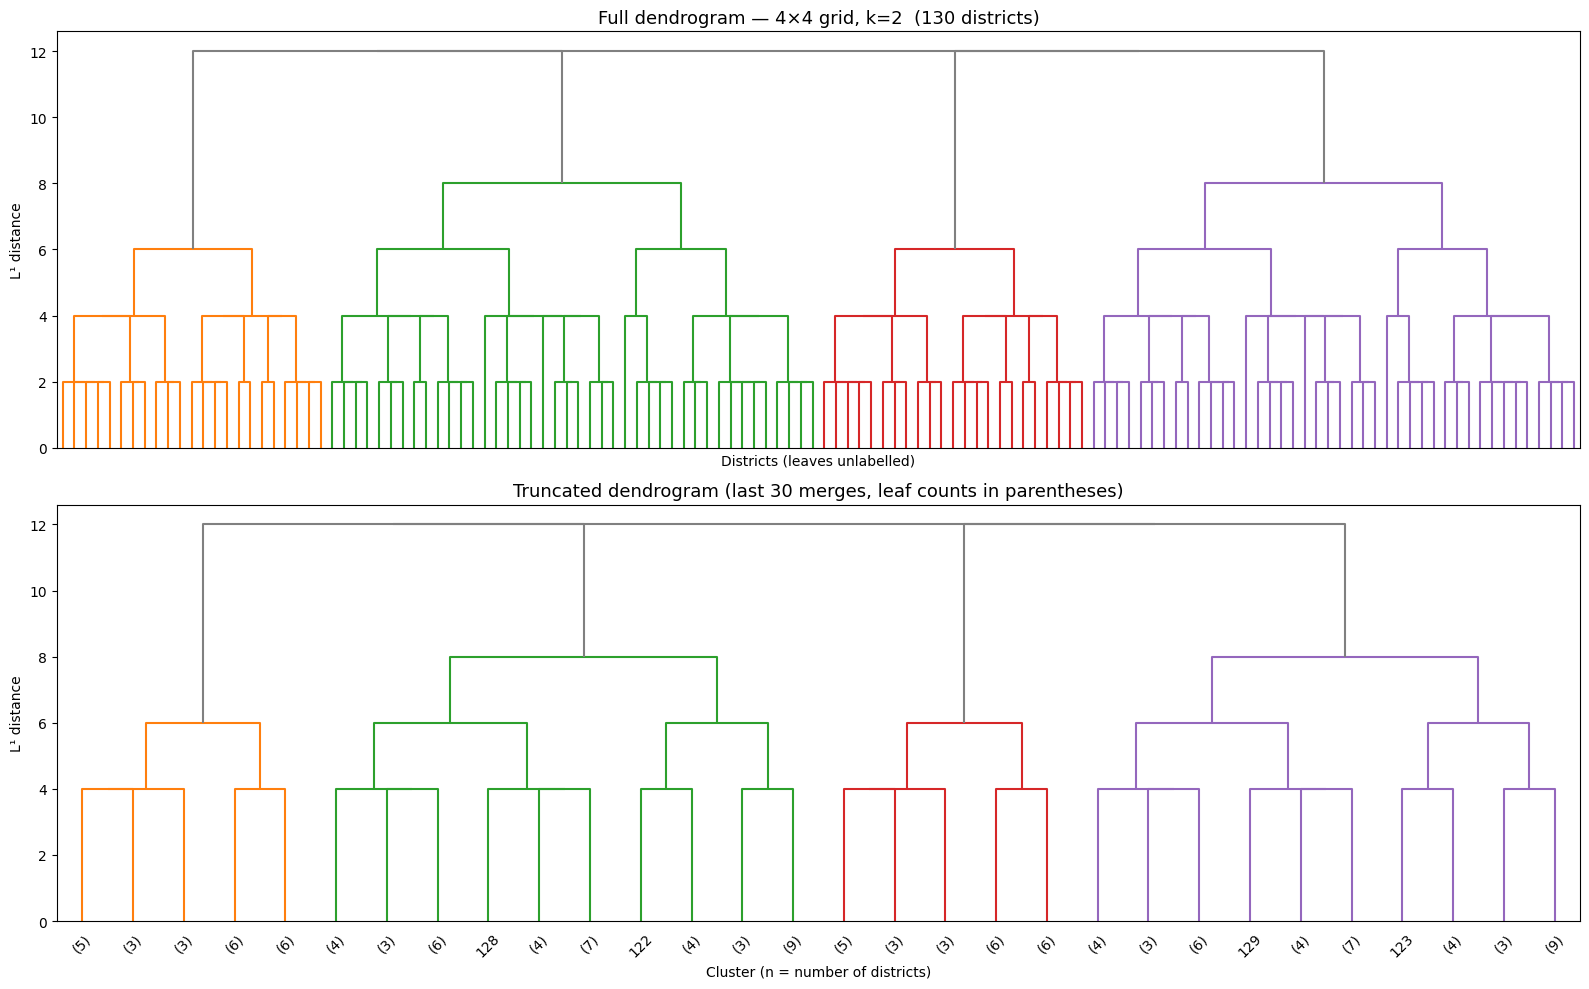

In [18]:
from scipy.cluster.hierarchy import dendrogram

Z = np.load(f"local/output/grid{N}x{N}_k{k}/processed/linkage.npy").astype(float)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# full dendrogram — all 130 leaves, no labels (too dense to read)
dendrogram(Z, ax=axes[0], no_labels=True, color_threshold=0.7 * Z[:, 2].max(),
           above_threshold_color="grey")
axes[0].set_title(f"Full dendrogram — {N}×{N} grid, k={k}  ({len(Z)+1} districts)", fontsize=13)
axes[0].set_ylabel("L¹ distance")
axes[0].set_xlabel("Districts (leaves unlabelled)")

# truncated dendrogram — collapse to last 30 merges for readability
dendrogram(Z, ax=axes[1], truncate_mode="lastp", p=30,
           color_threshold=0.7 * Z[:, 2].max(), above_threshold_color="grey",
           show_leaf_counts=True)
axes[1].set_title("Truncated dendrogram (last 30 merges, leaf counts in parentheses)", fontsize=13)
axes[1].set_ylabel("L¹ distance")
axes[1].set_xlabel("Cluster (n = number of districts)")

plt.tight_layout()
plt.show()

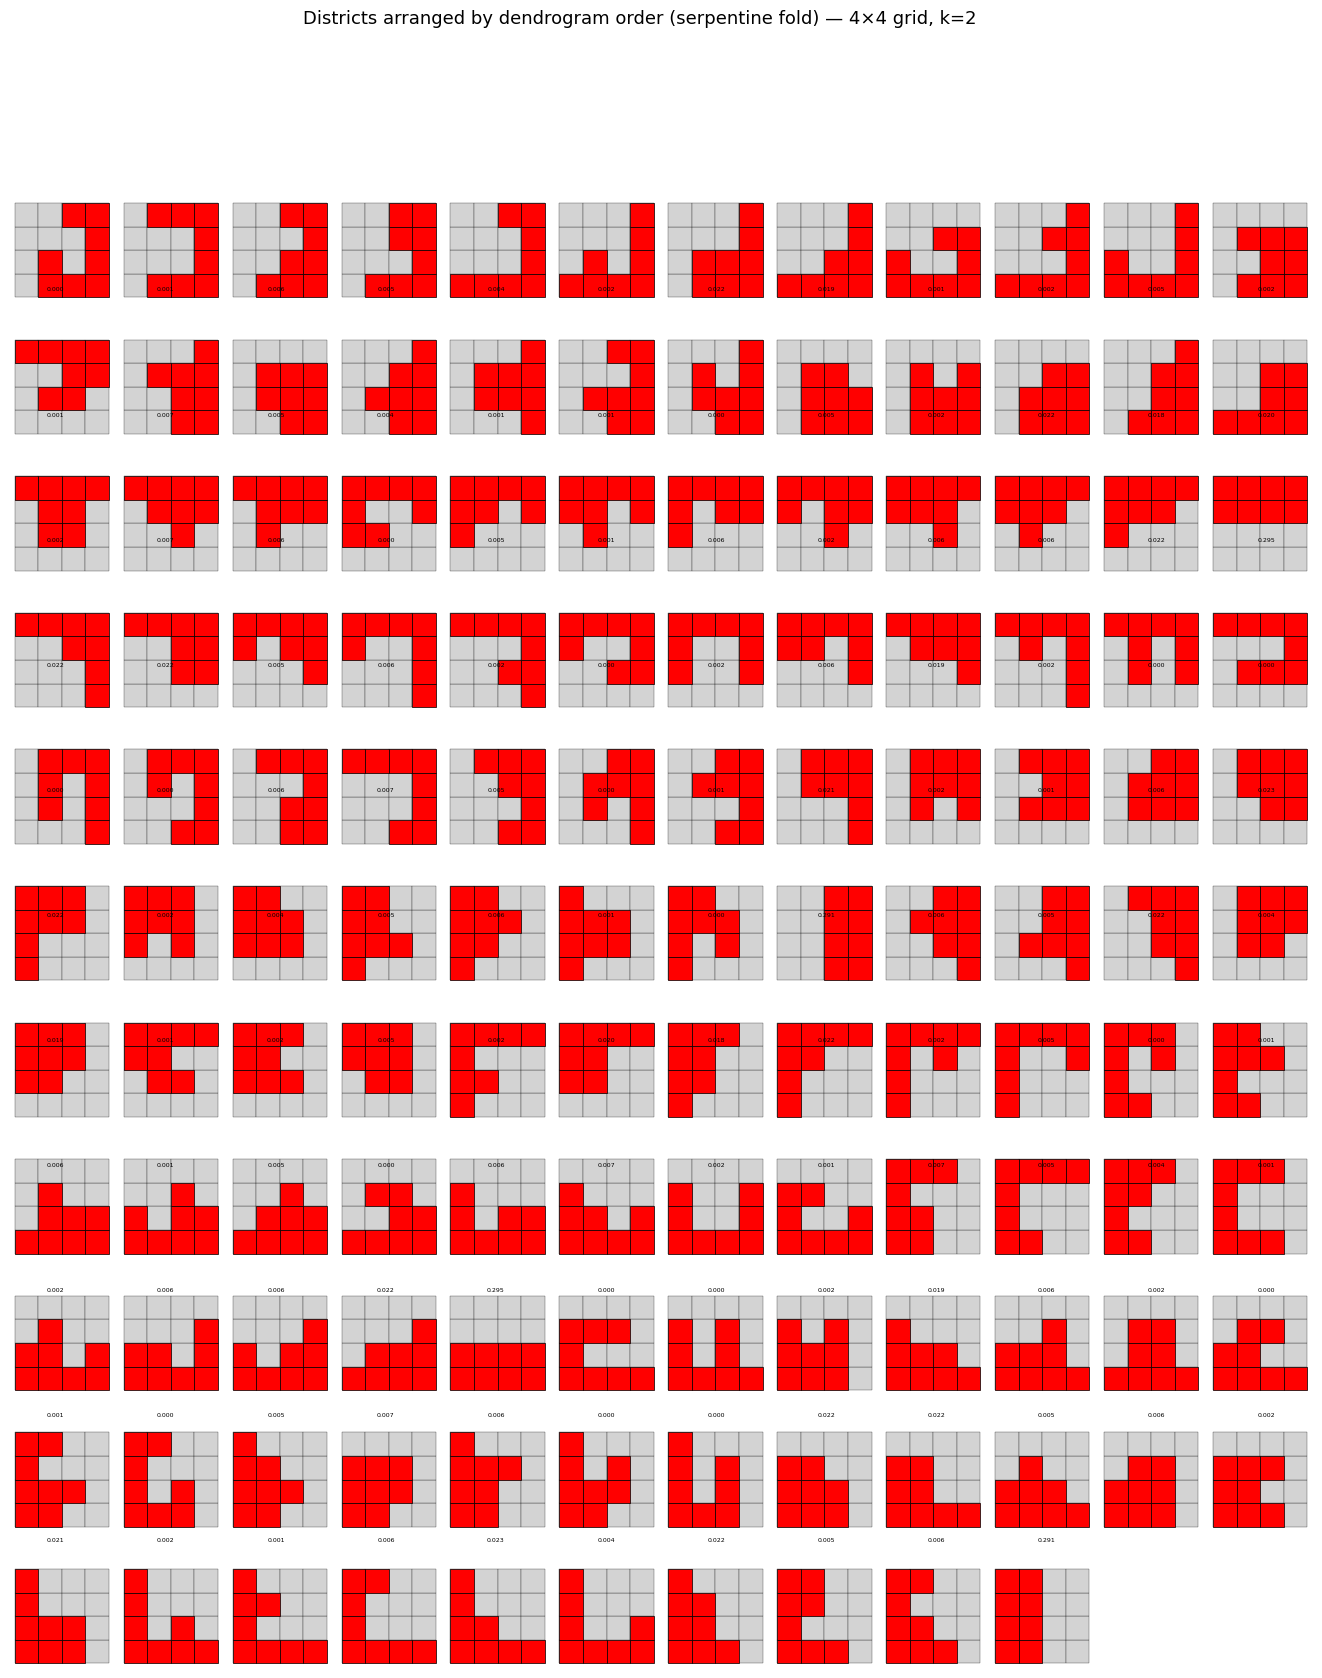

In [19]:
import math
import pandas as pd
from scipy.cluster.hierarchy import leaves_list
from utils import plot_district, str_to_vec

# leaf order from the dendrogram (left-to-right traversal)
Z = np.load(f"local/output/grid{N}x{N}_k{k}/processed/linkage.npy").astype(float)
leaf_order = leaves_list(Z)          # shape (130,): district_uid at each rank

df_districts = pd.read_feather(f"local/output/grid{N}x{N}_k{k}/processed/districts.feather")
uid_to_str  = df_districts.set_index("district_uid")["district_str"].to_dict()
uid_to_freq = df_sorted.set_index("district_uid")["freq"].to_dict()
gdf = generate_grid_shape(N)

# fold 1-D dendrogram order into a 2-D grid using a serpentine (boustrophedon) path
# so that adjacent ranks stay adjacent across row boundaries
ncols = math.ceil(math.sqrt(len(leaf_order)))
nrows = math.ceil(len(leaf_order) / ncols)

def serpentine_pos(rank, ncols):
    row = rank // ncols
    col = rank % ncols if row % 2 == 0 else ncols - 1 - (rank % ncols)
    return row, col

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.4, nrows * 1.6))
fig.suptitle(
    f"Districts arranged by dendrogram order (serpentine fold) — {N}×{N} grid, k={k}",
    fontsize=13,
)

used = set()
for rank, uid in enumerate(leaf_order):
    row, col = serpentine_pos(rank, ncols)
    used.add((row, col))
    ax = axes[row, col]
    plot_district(gdf, str_to_vec(uid_to_str[uid]), ax=ax)

for r in range(nrows):
    for c in range(ncols):
        if (r, c) not in used:
            axes[r, c].set_visible(False)

fig.canvas.draw()
for rank, uid in enumerate(leaf_order):
    row, col = serpentine_pos(rank, ncols)
    ax  = axes[row, col]
    pos = ax.get_position()
    fig.text(
        pos.x0 + pos.width / 2, pos.y0 - 0.002,
        f"{uid_to_freq.get(uid, 0):.3f}",
        ha="center", va="top", fontsize=4.5,
    )

plt.subplots_adjust(bottom=0.03, hspace=0.05, wspace=0.05)
plt.show()

/Users/ag245/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/ag245/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


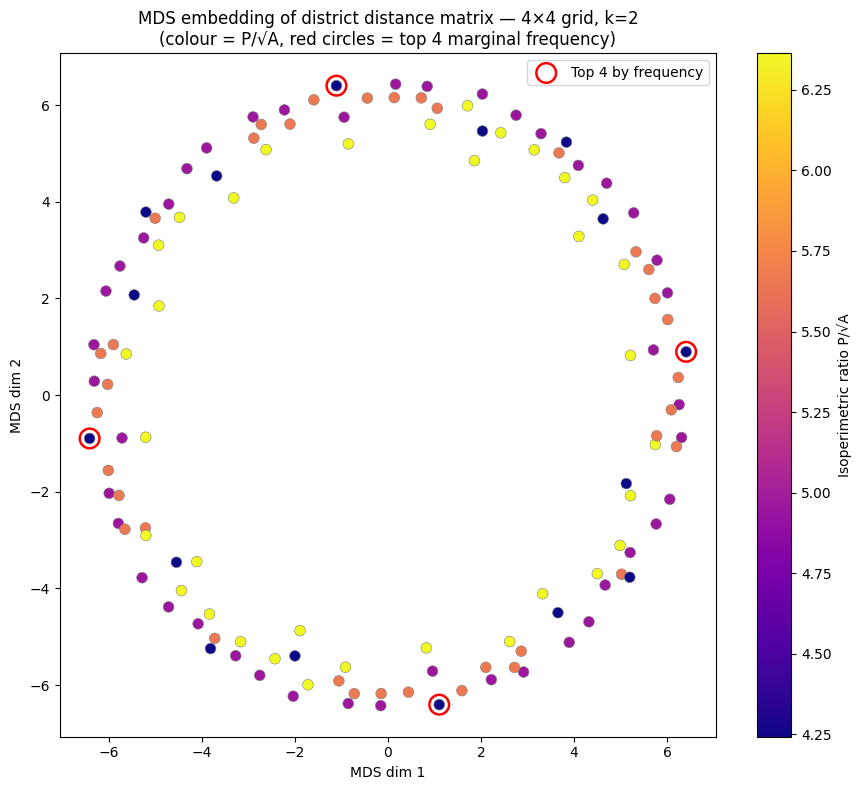

MDS stress: 19327.1950
Top 4 districts by frequency:
  uid=4  freq=0.2947  P/√A=4.24  8.9.10.11.12.13.14.15
  uid=5  freq=0.2947  P/√A=4.24  0.1.2.3.4.5.6.7
  uid=0  freq=0.2912  P/√A=4.24  0.1.4.5.8.9.12.13
  uid=1  freq=0.2912  P/√A=4.24  2.3.6.7.10.11.14.15


In [20]:
import pandas as pd
from sklearn.manifold import MDS
from utils import str_to_vec

D = np.load(f"local/output/grid{N}x{N}_k{k}/processed/distance_matrix.npy").astype(float)

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress="auto")
coords = mds.fit_transform(D)   # shape (130, 2)

df_districts = pd.read_feather(f"local/output/grid{N}x{N}_k{k}/processed/districts.feather")
uid_to_str  = df_districts.set_index("district_uid")["district_str"].to_dict()
uid_to_freq = df_sorted.set_index("district_uid")["freq"].to_dict()

ratios = np.array([
    isoperimetric_ratio(str_to_vec(uid_to_str[uid]).tolist(), N)
    for uid in range(len(coords))
])
freqs = np.array([uid_to_freq[uid] for uid in range(len(coords))])

top4_idx = np.argsort(freqs)[-4:]

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=ratios, cmap="plasma",
                s=60, linewidths=0.4, edgecolors="grey", zorder=2)
plt.colorbar(sc, ax=ax, label="Isoperimetric ratio P/√A")

ax.scatter(coords[top4_idx, 0], coords[top4_idx, 1],
           s=200, facecolors="none", edgecolors="red", linewidths=1.8, zorder=3,
           label="Top 4 by frequency")
ax.legend(loc="best", fontsize=10)

ax.set_title(
    f"MDS embedding of district distance matrix — {N}×{N} grid, k={k}\n"
    f"(colour = P/√A, red circles = top 4 marginal frequency)",
    fontsize=12,
)
ax.set_xlabel("MDS dim 1")
ax.set_ylabel("MDS dim 2")
plt.tight_layout()
plt.show()

print(f"MDS stress: {mds.stress_:.4f}")
print("Top 4 districts by frequency:")
for uid in top4_idx[np.argsort(freqs[top4_idx])[::-1]]:
    print(f"  uid={uid}  freq={freqs[uid]:.4f}  P/√A={ratios[uid]:.2f}  {uid_to_str[uid]}")

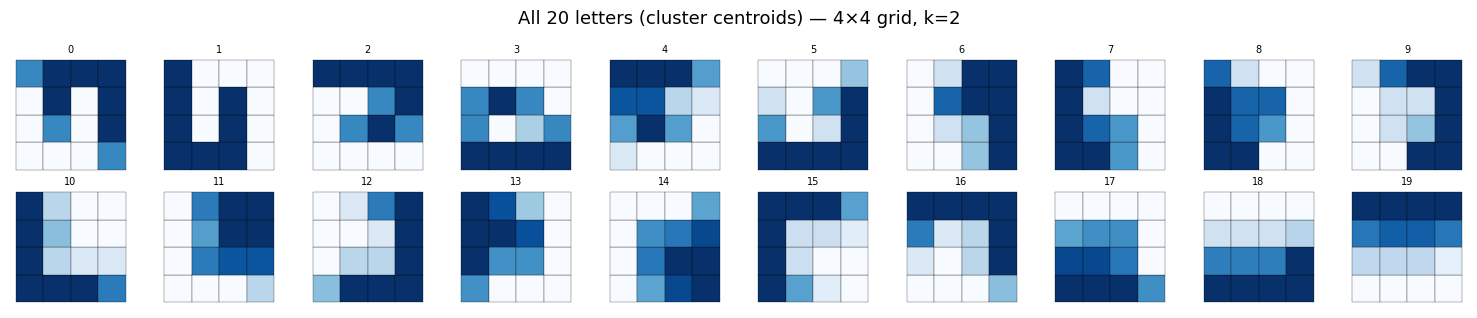

In [22]:
import math
from utils import plot_distribution

N, k   = 4, 2
tag    = f"{N}x{N}_k{k}"
hc     = results[tag]["hc"]
gdf    = generate_grid_shape(N)

densities   = hc.cluster_densities          # shape (num_letters, num_precincts)
num_letters = len(densities)

ncols = 10
nrows = math.ceil(num_letters / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.6))
fig.suptitle(f"All {num_letters} letters (cluster centroids) — {N}×{N} grid, k={k}", fontsize=13)

for i, ax in enumerate(axes.flat):
    if i < num_letters:
        plot_distribution(gdf, densities[i], ax=ax, cmap="Blues", vmin=0, vmax=1)
        ax.set_title(str(i), fontsize=7, pad=1)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

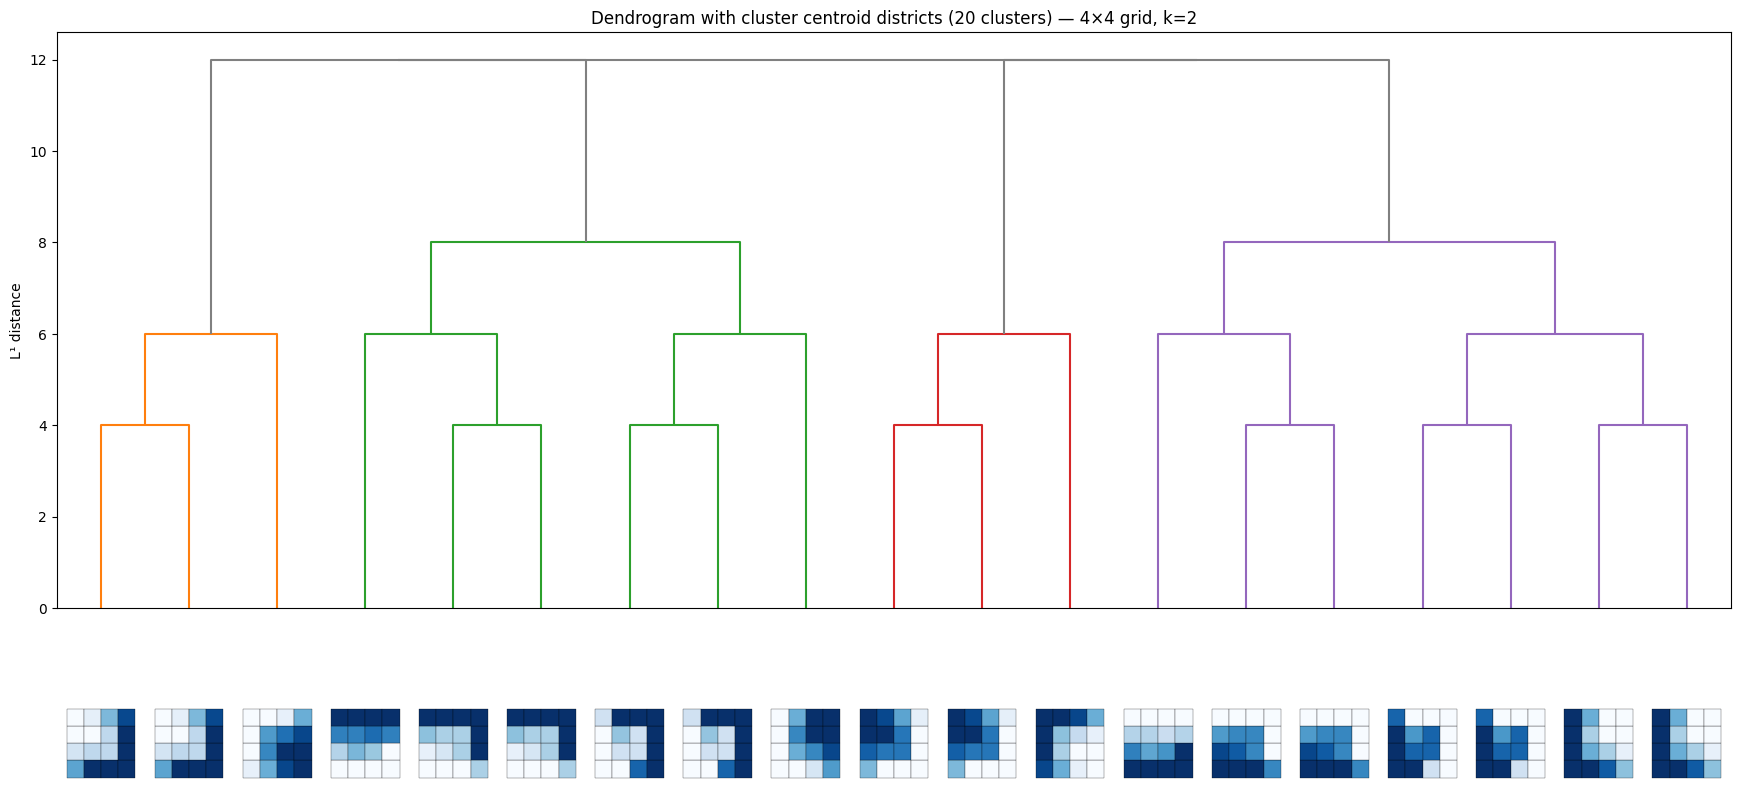

In [23]:
from scipy.cluster.hierarchy import dendrogram, fcluster
from utils import plot_distribution

N, k = 4, 2
tag  = f"{N}x{N}_k{k}"
hc   = results[tag]["hc"]
gdf  = generate_grid_shape(N)

Z  = hc.linkage.astype(float)
n  = hc.num_vertices   # 130
K  = hc.num_clusters   # 20

# tree-cut cluster assignments (0-indexed)
fc_labels = fcluster(Z, t=K, criterion='maxclust') - 1

# centroid densities from the tree cut
all_dists = hc.sp.get_all_districts()
n_prec    = hc.sp.num_precincts
tree_dens = np.zeros((K, n_prec))
tree_cnt  = np.zeros(K, dtype=int)
for uid, cid in enumerate(fc_labels):
    tree_dens[cid, all_dists[uid]] += 1
    tree_cnt[cid] += 1
for cid in range(K):
    if tree_cnt[cid] > 0:
        tree_dens[cid] /= tree_cnt[cid]

def subtree_leaves(node_id):
    if node_id < n:
        return [node_id]
    i = node_id - n
    return subtree_leaves(int(Z[i, 0])) + subtree_leaves(int(Z[i, 1]))

iw = 0.042   # inset width  — fits 20 leaves with a little gap
ih = 0.30    # inset height — tall enough to see the 4×4 grid clearly

ax_bottom = ih + 0.02   # reserve space below the dendrogram axes
fig = plt.figure(figsize=(18, 9))
ax  = fig.add_axes([0.05, ax_bottom, 0.93, 0.96 - ax_bottom])

dend = dendrogram(
    Z, ax=ax,
    truncate_mode='lastp', p=K - 1,
    no_labels=True,
    color_threshold=0.7 * Z[:, 2].max(),
    above_threshold_color='grey',
)
ax.set_title(
    f"Dendrogram with cluster centroid districts ({K} clusters) — {N}×{N} grid, k={k}",
    fontsize=12,
)
ax.set_ylabel("L¹ distance")
ax.tick_params(bottom=False)

# remove bottom y-padding so y=0 (leaves) maps exactly to the axes bottom edge
ax.set_ylim(bottom=0)
fig.canvas.draw()

leaf_ids   = dend['leaves']
leaf_x_dat = [5 + 10 * i for i in range(len(leaf_ids))]

for lid, xd in zip(leaf_ids, leaf_x_dat):
    x_px, y_px = ax.transData.transform((xd, 0))
    xf, yf     = fig.transFigure.inverted().transform((x_px, y_px))

    cid   = int(fc_labels[subtree_leaves(lid)[0]])
    ax_in = fig.add_axes([xf - iw / 2, yf - ih, iw, ih])
    plot_distribution(gdf, tree_dens[cid], ax=ax_in, cmap='Blues', vmin=0, vmax=1)

plt.show()